## ETI STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

eti=pd.read_csv('../stock_data/eti.csv') ## so it can be small letter. This is cool.
eti=eti.drop(columns=['high_price','low_price'])
eti.rename(columns={'trade_date':'date'},inplace=True)
eti['date']=pd.to_datetime(eti['date'])
eti['month']=eti['date'].dt.month
eti['quarter']=eti['date'].dt.quarter
eti['year']=eti['date'].dt.year

eti

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42806,ETI,2017-01-03,9.77,9.77,1549510,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43366,ETI,2017-01-04,9.54,9.54,900911,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43476,ETI,2017-01-05,9.73,9.73,778336,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43586,ETI,2017-01-06,9.85,9.85,17144388,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43676,ETI,2017-01-09,10.00,10.00,444735,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298056,ETI,2026-07-13,85.70,85.70,1255880,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298494,ETI,2026-07-14,85.70,85.70,4345556,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298932,ETI,2026-07-15,85.70,85.70,739986,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299370,ETI,2026-07-16,85.70,85.70,903579,2026-07-16T15:10:03.113936+00:00,7,3,2026


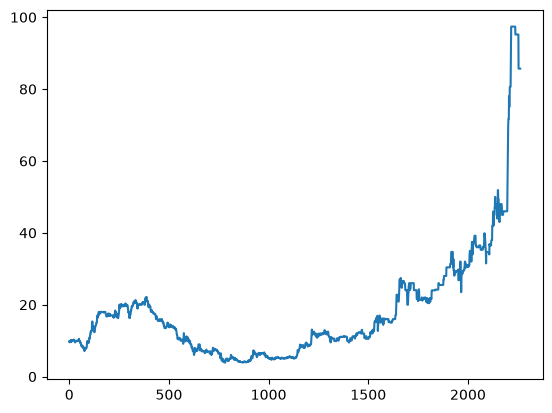

In [2]:
import matplotlib.pyplot as plt

plt.plot(eti['close_price'])
plt.show()

In [3]:
eti_end_month_df = (
    eti
    .sort_values("date")
    .groupby(eti["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

eti_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45376,ETI,2017-01-31,10.15,10.15,2899534,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47197,ETI,2017-02-28,9.96,9.96,2616048,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49313,ETI,2017-03-31,8.70,8.70,285762,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51141,ETI,2017-04-28,7.71,7.71,182120,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53063,ETI,2017-05-31,10.60,10.60,1934193,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35294,ETI,2026-03-31,46.00,46.00,681561,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281120,ETI,2026-04-30,80.60,80.60,3765949,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284186,ETI,2026-05-29,97.40,97.40,355093,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294114,ETI,2026-06-30,95.20,95.20,10585,2026-06-30T15:10:03.08168+00:00,6,2,2026


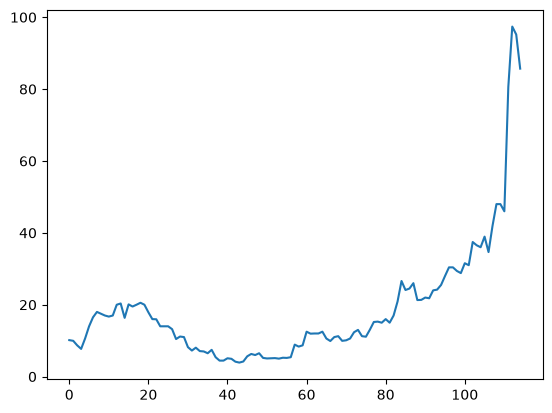

In [4]:
plt.plot(eti_end_month_df['close_price'])
plt.show()

In [5]:
eti_end_month_df['returns']=eti_end_month_df['close_price'].pct_change()*100
eti_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45376,ETI,2017-01-31,10.15,10.15,2899534,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47197,ETI,2017-02-28,9.96,9.96,2616048,2026-04-08T02:44:45.006295+00:00,2,1,2017,-1.871921
2,49313,ETI,2017-03-31,8.70,8.70,285762,2026-04-08T02:45:42.281198+00:00,3,1,2017,-12.650602
3,51141,ETI,2017-04-28,7.71,7.71,182120,2026-04-08T02:51:55.619599+00:00,4,2,2017,-11.379310
4,53063,ETI,2017-05-31,10.60,10.60,1934193,2026-04-08T02:52:57.421655+00:00,5,2,2017,37.483787
...,...,...,...,...,...,...,...,...,...,...,...
110,35294,ETI,2026-03-31,46.00,46.00,681561,2026-03-31T15:00:02.085058+00:00,3,1,2026,-4.166667
111,281120,ETI,2026-04-30,80.60,80.60,3765949,2026-04-30T15:00:02.170664+00:00,4,2,2026,75.217391
112,284186,ETI,2026-05-29,97.40,97.40,355093,2026-05-29T15:00:02.455558+00:00,5,2,2026,20.843672
113,294114,ETI,2026-06-30,95.20,95.20,10585,2026-06-30T15:10:03.08168+00:00,6,2,2026,-2.258727


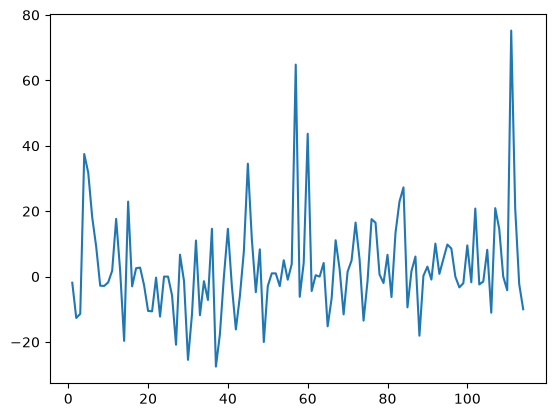

In [6]:
plt.plot(eti_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(eti_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-9.520305223121786), np.float64(3.0775843860808977e-16), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(832.5608547428845))
stationary


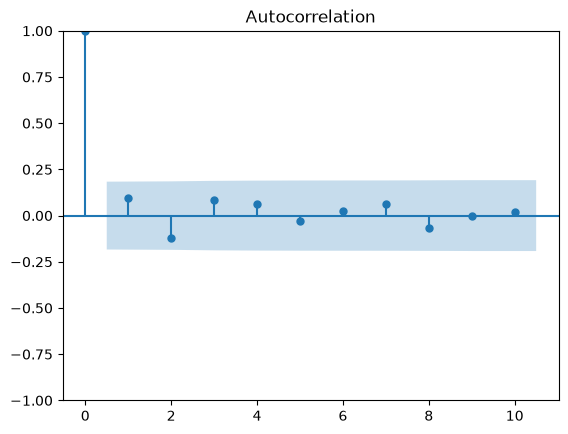

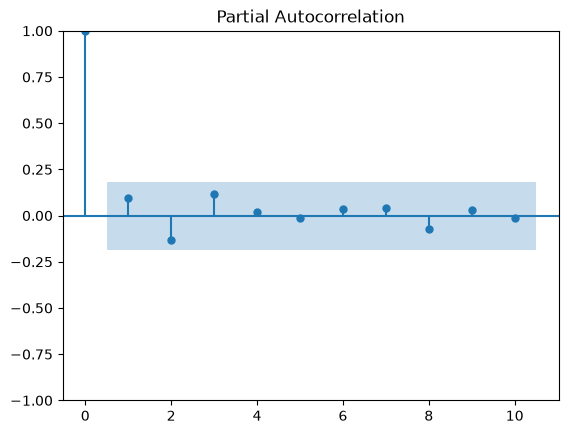

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(eti_end_month_df['returns'].dropna(), lags=10)
plot_pacf(eti_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=eti_end_month_df['close_price'][:-10]
test=eti_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -6.793186376973438]
[0, 0, 0, 0, 0, 1, -4.1665033455929255]
[0, 0, 0, 0, 0, 2, -2.496772368961709]
[0, 0, 0, 0, 1, 0, -1.6566249884455617]
[0, 0, 0, 0, 1, 1, -1.4535808312388214]
[0, 0, 0, 0, 1, 2, -1.4196759818732998]
[0, 0, 0, 0, 2, 0, -0.8015782513025949]
[0, 0, 0, 0, 2, 1, -0.8951945685642491]
[0, 0, 0, 0, 2, 2, -0.9717224139472147]
[0, 0, 0, 1, 0, 0, -1.8456440726819148]
[0, 0, 0, 1, 0, 1, -1.7002684448091547]
[0, 0, 0, 1, 0, 2, -1.653653273069411]
[0, 0, 0, 1, 1, 0, -1.3583689869045847]
[0, 0, 0, 1, 1, 1, -1.4269974977821396]
[0, 0, 0, 1, 1, 2, -1.5817209632056013]
[0, 0, 0, 1, 2, 0, -0.7735611850269564]
[0, 0, 0, 1, 2, 1, -1.028383381775737]
[0, 0, 0, 1, 2, 2, -0.9842961159781176]
[0, 0, 0, 2, 0, 0, -1.5807792355744423]
[0, 0, 0, 2, 0, 1, -1.670254049359912]
[0, 0, 0, 2, 0, 2, -1.4919265767623582]
[0, 0, 0, 2, 1, 0, -1.447561213632674]
[0, 0, 0, 2, 1, 1, -1.5235349369531765]
[0, 0, 0, 2, 1, 2, -1.527741754316466]
[0, 0, 0, 2, 2, 0, -0.9235074129692897]
[0, 0, 

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-6.793186
27,0,0,1,0,0,0,-6.569039
54,0,0,2,0,0,0,-6.409413
1,0,0,0,0,0,1,-4.166503
28,0,0,1,0,0,1,-4.067995
...,...,...,...,...,...,...,...
691,2,2,1,1,2,1,-0.087515
717,2,2,2,1,2,0,-0.081654
690,2,2,1,1,2,0,-0.075570
718,2,2,2,1,2,1,-0.073902


NO good model.

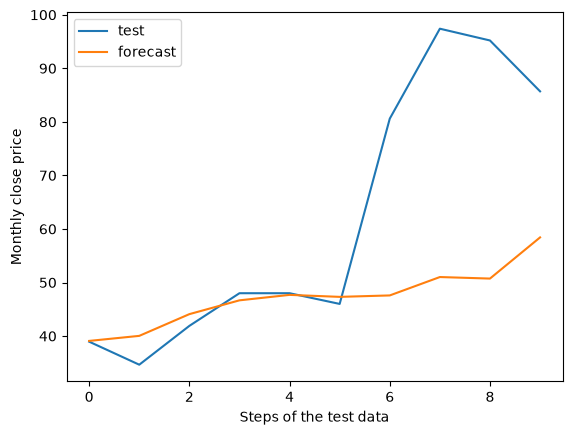

r2_score:  -0.07270899152511556
rmse:  24.494401116786296
description:  count    115.000000
mean      18.652087
std       16.981433
min        3.900000
25%        8.525000
50%       14.000000
75%       21.575000
max       97.400000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=eti_end_month_df['close_price'][:-10]
y_test=eti_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,2), 
seasonal_order=(0,2,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', eti_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=eti_end_month_df['returns'].dropna()[:-10]
test=eti_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.21771243152412878]
[0, 0, 0, 0, 0, 1, -0.22269011719492315]
[0, 0, 0, 0, 0, 2, -0.21680071239920085]
[0, 0, 0, 0, 1, 0, -0.29977134348770385]
[0, 0, 0, 0, 1, 1, -0.147673451696825]
[0, 0, 0, 0, 1, 2, -0.16522397299397817]
[0, 0, 0, 0, 2, 0, -0.9504333310042838]
[0, 0, 0, 0, 2, 1, -0.29462674385001675]
[0, 0, 0, 0, 2, 2, -0.20923086306163596]
[0, 0, 0, 1, 0, 0, -0.21366663362640748]
[0, 0, 0, 1, 0, 1, -0.21064062775610082]
[0, 0, 0, 1, 0, 2, -0.18217631483329488]
[0, 0, 0, 1, 1, 0, -0.22434886270510823]
[0, 0, 0, 1, 1, 1, -0.1595400458259819]
[0, 0, 0, 1, 1, 2, -0.1684970137536943]
[0, 0, 0, 1, 2, 0, -0.46521103190379054]
[0, 0, 0, 1, 2, 1, -0.2612398336409112]
[0, 0, 0, 1, 2, 2, -0.10037832250974232]
[0, 0, 0, 2, 0, 0, -0.21249734710545076]
[0, 0, 0, 2, 0, 1, -0.17891511898854695]
[0, 0, 0, 2, 0, 2, -0.18382877188947822]
[0, 0, 0, 2, 1, 0, -0.19783184639456164]
[0, 0, 0, 2, 1, 1, -0.18081773618773256]
[0, 0, 0, 2, 1, 2, -0.08110167646754185]
[0, 0, 0, 2, 2, 0, -0.

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
177,0,2,0,1,2,0,-41.587269
422,1,2,0,1,2,2,-29.522923
431,1,2,0,2,2,2,-28.501105
413,1,2,0,0,2,2,-28.228008
421,1,2,0,1,2,1,-26.020356
...,...,...,...,...,...,...,...
643,2,1,2,2,1,2,-0.032947
463,1,2,2,0,1,1,-0.024598
473,1,2,2,1,1,2,-0.023696
401,1,1,2,2,1,2,-0.011778


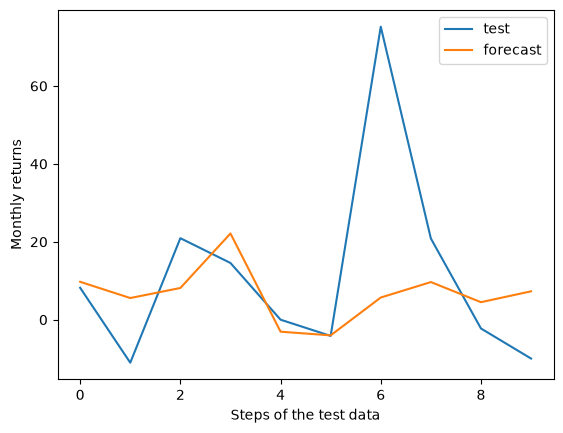

r2_score:  -0.003288451289248595
rmse:  24.106003871752883
description:  count    114.000000
mean       2.915013
std       15.423338
min      -27.516779
25%       -4.341667
50%        0.000000
75%        8.511905
max       75.217391
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=eti_end_month_df['returns'].dropna()[:-10]
y_test=eti_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,2,2), 
seasonal_order=(2,1,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', eti_end_month_df.returns.dropna().describe())

Very horrible.


We will have to revisit this No model worked well.